In [4]:
%load_ext autoreload
%autoreload 2

In [1]:
print("hje")

hje


In [5]:
import torch
torch.rand(5,1,3,2).shape[2:]

torch.Size([3, 2])

In [9]:
import importlib
from PIL import Image
from pathlib import Path
import src.models.lit_vgg as lit_vgg_module
import torchvision
import src.visualization.gradcam as gradcam_module

importlib.reload(lit_vgg_module)
importlib.reload(gradcam_module)


from src.models.lit_vgg import LitVGG
from src.visualization.gradcam import GradCAM 

image = Image.open(next(Path("data/train").rglob("*.jpg")))

lit_vgg = LitVGG.load_from_checkpoint(
    "checkpoints/vgg19_bn/vgg19_bn-epoch=7-valid_loss=0.31.ckpt",
    weights_only=False
)

gradcam = GradCAM(lit_vgg.model, lit_vgg.model.vgg.features[-4])

[INFO] VGG19 frozen: 143.7M params
[INFO] No attention (Baseline)
[INFO] Trainable params: 0.016M
[INFO] VGG19 frozen: 143.7M params
[INFO] No attention (Baseline)
[INFO] Trainable params: 0.016M


In [14]:
from src.data.augmentation import get_val_transforms
VGG19SEAttention()(get_val_transforms()(image).unsqueeze(0)).shape

[INFO] Using SE Attention
[INFO] Total params: 156.6M
[INFO] Frozen params: 143.7M
[INFO] Trainable params: 12.880M


torch.Size([1, 4])

In [18]:
from src.models.lit_vgg_attention import *

model = VGG19SoftmaxAttention()
model

[INFO] Using Softmax Attention
[INFO] Total params: 156.5M
[INFO] Frozen params: 143.7M
[INFO] Trainable params: 12.848M


VGG19SoftmaxAttention(
  (model): VGG19Model(
    (vgg): VGG(
      (features): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
        (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (9): ReLU(inplace=True)
        (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (12): ReLU(inplace=Tru

In [43]:
next(Path("data/train").rglob("*.jpg"))

WindowsPath('data/train/glioma/Tr-gl_1.jpg')

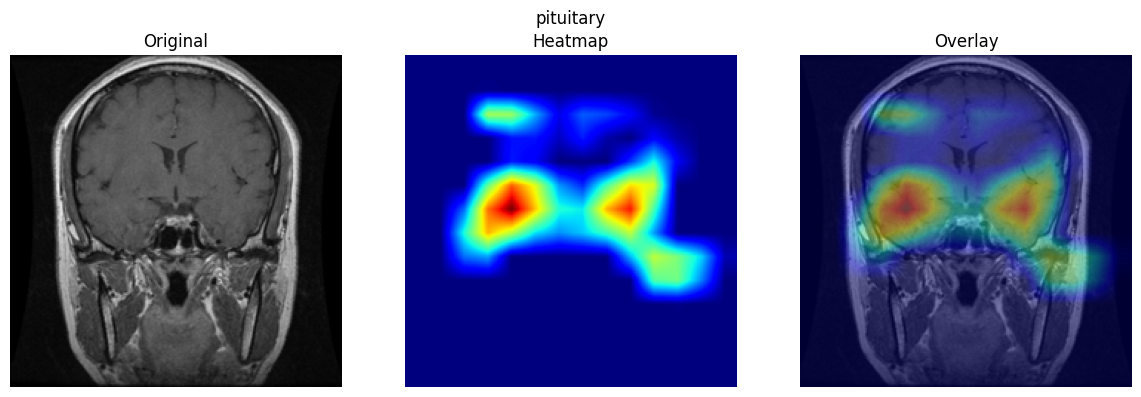

In [3]:
import matplotlib.pyplot as plt
fig  = gradcam.visualize(img_path=next(Path("data/train/pituitary").rglob("*.jpg")))

In [7]:
import random
random.choice(list(path.rglob("*.jpg"))[:5])

WindowsPath('data/val/pituitary/Tr-pi_100.jpg')

In [3]:
[path.name for path in list(Path("data/val/").glob("*/"))]

['glioma', 'meningioma', 'notumor', 'pituitary']

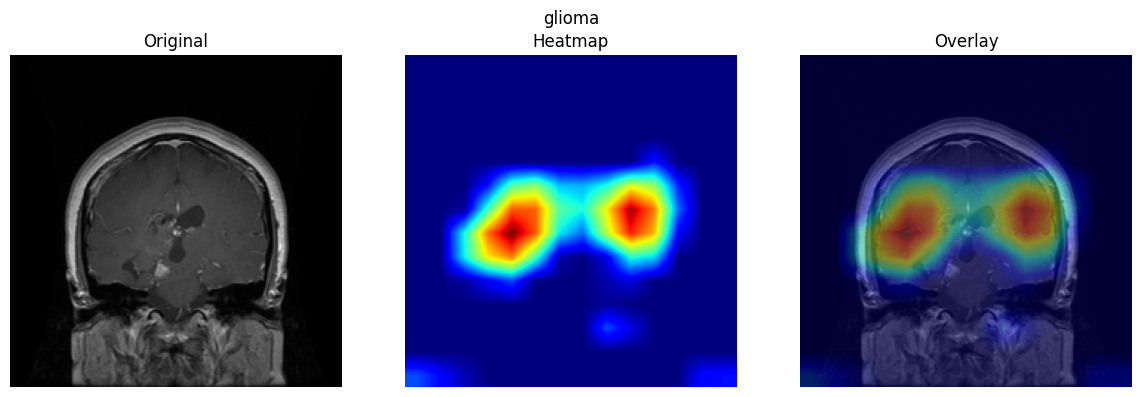

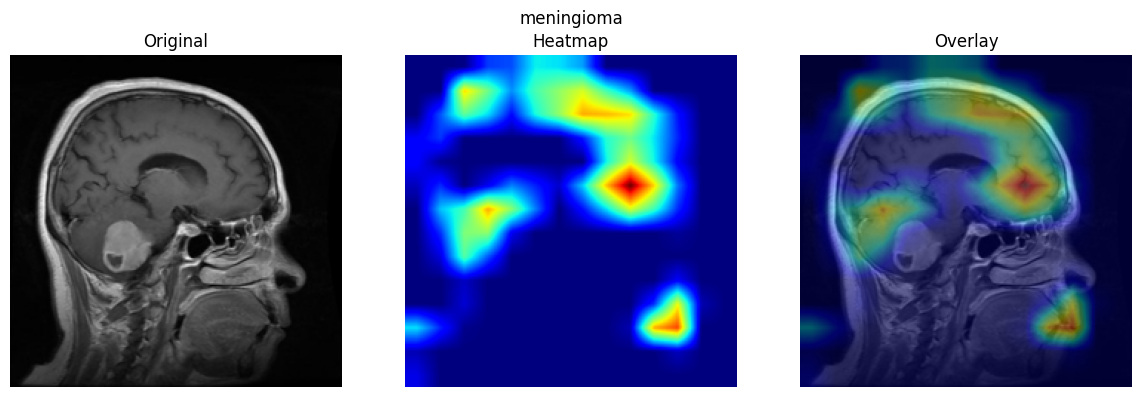

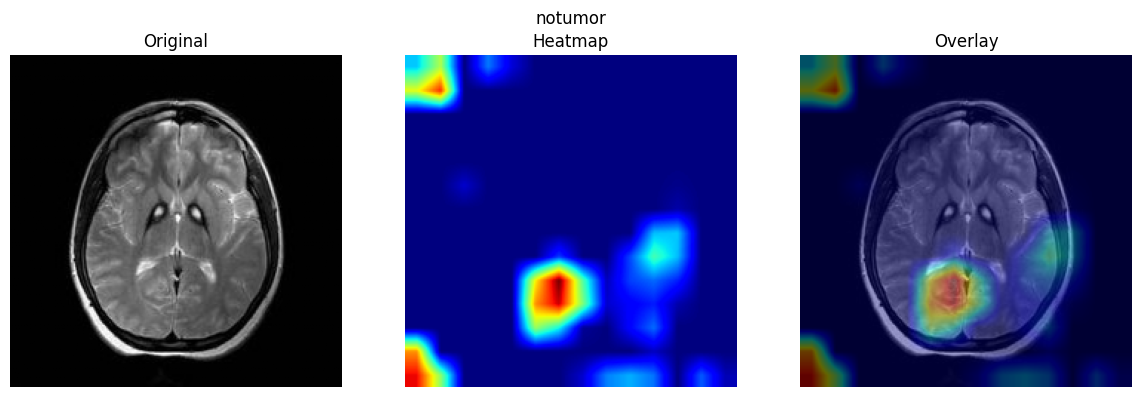

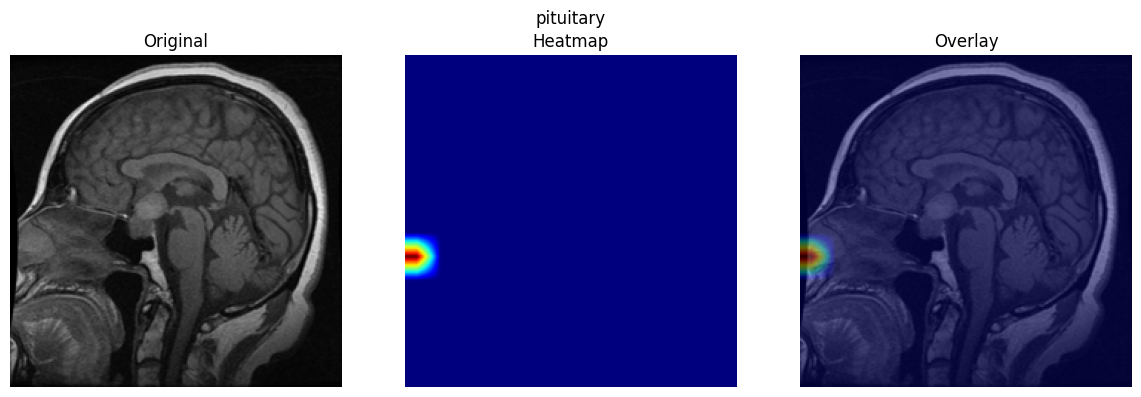

In [ ]:
import random
paths = list(Path("data/val/").glob("*/"))
for path in paths:
    gradcam.visualize(img_path=random.choice(list(path.rglob("*.jpg"))))

In [10]:
[path.name for path in paths]

['glioma', 'meningioma', 'notumor', 'pituitary']

In [9]:
str(paths[0]).splot

'data\\val\\glioma'

In [8]:
paths[0].name

'glioma'

In [17]:
weights.shape

torch.Size([1, 512, 1, 1])

In [18]:
activations.shape

torch.Size([1, 512, 14, 14])

In [16]:
model = lit_vgg.model
x = model.transforms(image.convert("RGB")).unsqueeze(0)
cam  = gradcam.generate(x)
gradients = gradcam.gradients
activations = gradcam.activations

# set model to eval and place input to same device
model.eval()
device = next(model.parameters()).device
x = x.to(device)

# make sure parameters are unfrozen
for param in model.parameters():
    param.requires_grad = True
logits = model(x)

# if no class provided, use predicted class
# if class_idx is None:
class_idx=logits.argmax(dim=1)

# backpropagation from target class
model.zero_grad()
logits[0, class_idx].backward()

# calculate gradcam
weights = gradients.mean(dim=[2,3], keepdim=True)
cam = (weights*activations).sum(dim=1, keepdim=True)
cam = torch.relu(cam)

cam

tensor([[[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0011, 0.0000, 0.0000,
           0.0007, 0.0011, 0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0043, 0.0070, 0.0052, 0.0073,
           0.0098, 0.0154, 0.0110, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0003, 0.0035, 0.0023, 0.0000, 0.0000,
           0.0017, 0.0183, 0.0215, 0.0088, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0016, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0117, 0.0209, 0.0123, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0082, 0.0080, 0.0080, 0.0031, 0.0026, 0.0003,
           0.0031, 0.0148, 0.0285, 0.0219, 0.0037, 0.0000],
          [0.0000, 0.0011, 0.0182, 0.0204, 0.0188, 0.0088, 0.0028, 0.0000,
           0.0030, 0.0147, 0.0297, 0.0234, 0.0054, 0.0000],
          [0.0000, 0.0026, 0.0182, 0.0227, 0.0181, 0.00

In [36]:
lit_vgg.model.vgg.features[-5:]

Sequential(
  (48): ReLU(inplace=True)
  (49): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (50): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (51): ReLU(inplace=True)
  (52): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)

In [11]:
lit_vgg.model(img_test.to("cuda")).cpu()

tensor([[ 3.7711, -1.4053, -2.8846, -3.8170]], grad_fn=<ToCopyBackward0>)

In [1]:
print("h")

h


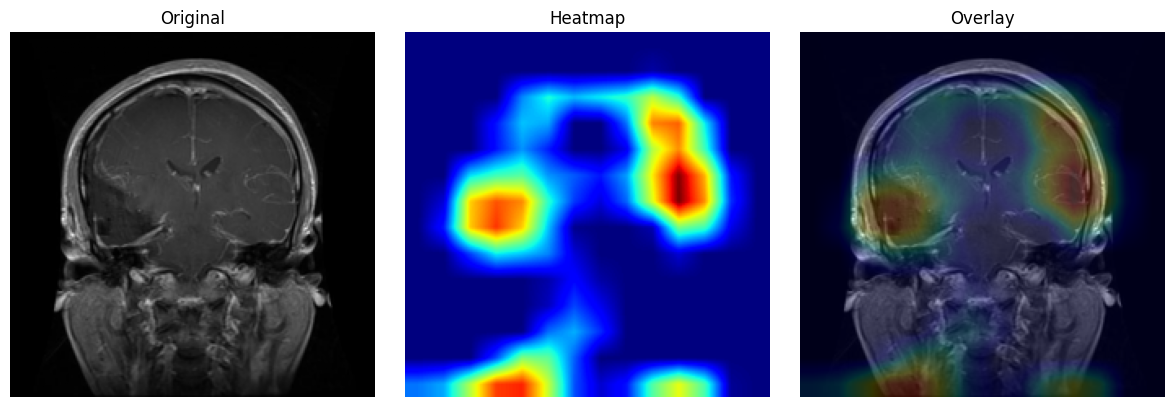

In [32]:
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np

cam = gradcam.generate(img_test)
cam = F.interpolate(cam, size=img_test.shape[2:], mode="bilinear", align_corners=False)
cam = cam.squeeze().detach().cpu().numpy()
cam = (cam-cam.min())/(cam.max()-cam.min())

img = np.array(image.convert("RGB").resize((img_test.shape[3], img_test.shape[2])))/255.0

heatmap = plt.cm.jet(cam)[:,:,:3]

alpha = 0.2
overlay = alpha*heatmap + (1-alpha)*img

fig, axes = plt.subplots(1, 3, figsize=(12,4))
axes[0].imshow(img)
axes[0].set_title("Original")
axes[1].imshow(heatmap)
axes[1].set_title("Heatmap")
axes[2].imshow(overlay)
axes[2].set_title("Overlay")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [19]:
plt.cm.jet(cam).shape

(224, 224, 4)

In [16]:
import torchvision
data_transforms = torchvision.models.VGG19_BN_Weights.DEFAULT.transforms()

In [20]:
import numpy as np
np.array(image).shape

(512, 512)

In [39]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

data_transforms = torchvision.models.VGG19_BN_Weights.DEFAULT.transforms()

train_dir = "data/train"
train_dataset = datasets.ImageFolder(root=train_dir, transform=data_transforms)
train_dataloader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

In [ ]:
from PIL import Image
from pathlib import Path



In [1]:
import torch
print(torch.cuda.is_available())

True


In [1]:
!nvidia-smi

Mon Apr 13 17:12:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.94                 Driver Version: 560.94         CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4060 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   40C    P0             13W /  100W |       0MiB /   8188MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
print(torch.cuda.get_device_name(0)) # Should show your dedicated GPU

: 

In [30]:
for image, label in train_dataloader:
    print(image.shape)
    break

torch.Size([64, 3, 224, 224])


In [34]:
import torch

out = model(image)

In [36]:
pred = model(image[[0]])

In [38]:
pred.argmax(dim=1)

tensor([0])

In [ ]:
data_transforms = torchvision.models.VGG19_BN_Weights.DEFAULT.transforms()